In [1]:
## General imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
import seaborn as sns
import pandas as pd
import pingouin as pg
## Latex fonts
from set_tex_fonts import set_latex_font

In [2]:
# Size of one plot and resolution
pltSizex = 10
pltSizey = 10
dpi = 300
# Fontsize for the different parameters
legFont = 55
xTitleFont = 50
yTitleFont = 50
xLabelFont = 40
yLabelFont = 40
# Set latex font for plots
set_latex_font()

In [3]:
## Parameters
ablationsList = ['None', 'all_but_pos', 'all_but_posvel', 'forcestorques', 'all_but_forcestorques', 'all_but_forcestorquesant', 'velocity', 'anthropo', 'forces', 'torques', 'Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
ablLabels     = [r'Full',r'$\mathbf{q}_r$', r'$[\mathbf{q}_r, \dot{\mathbf{q}}_r]$', r'$[\mathbf{q}_r, \dot{\mathbf{q}}_r, \mathbf{\ell}_h]$', r'$[\mathbf{F}_i, \dot{\bm{\tau}}_i]$', r'$[\mathbf{F}_i, \dot{\bm{\tau}}_i, \mathbf{\ell}_h]$', r'$\overline{\dot{\mathbf{q}}_r}$', r'$\overline{\mathbf{\ell}_h}$', r'$\overline{\mathbf{F}_i}$', r'$\overline{\bm{\tau}_i}$', r'$\overline{F_x}$', r'$\overline{F_y}$', r'$\overline{F_z}$', r'$\overline{\tau_x}$', r'$\overline{\tau_y}$', r'$\overline{\tau_z}$']
outTypesList  = ['pos', 'vel', 'posvel']
foldsList     = ['2-fold', '3-fold']
jointsList    = ['shoulder', 'elbow']
nb_HC_order   = ['8','16','32','64','128']

In [4]:
## Import all fitting results
all_FNOFittings = pd.read_csv('./all_params/all_FNO_fitting_results.csv', keep_default_na = False, na_values = ['NaN', 'N/A', ''])

In [11]:
## Get minimum averaged position errors
all_FNOFittingsEval = all_FNOFittings[all_FNOFittings['type'] == 'eval']
all_FNOFittingsShort = all_FNOFittingsEval[['ablation', 'predicted', 'dataType', 'fold', 'joint', 'FNO_shuff', 'FNO_batch', 'FNO_nbMod', 'FNO_nbHC', 'FNO_maxIt', 'posRMSE', 'velRMSE', 'posAAE', 'velAAE', 'tauRMSE', 'tauAAE']]
all_FNOFittingsShort_av = all_FNOFittingsShort.groupby(['ablation', 'predicted', 'dataType', 'fold', 'joint', 'FNO_shuff', 'FNO_batch', 'FNO_nbMod', 'FNO_nbHC', 'FNO_maxIt']).mean().reset_index()
all_FNOFittingsShort_av_e = all_FNOFittingsShort_av[all_FNOFittingsShort_av['joint'] == 'elbow']
all_FNOFittingsShort_av_s = all_FNOFittingsShort_av[all_FNOFittingsShort_av['joint'] == 'shoulder']

row_min_err_e = all_FNOFittingsShort_av_e.loc[all_FNOFittingsShort_av_e['posAAE'].idxmin()]
row_min_err_s = all_FNOFittingsShort_av_s.loc[all_FNOFittingsShort_av_s['posAAE'].idxmin()]

# print(row_min_err_e)
print(row_min_err_s)

ablation       forces
predicted         pos
dataType         FULL
fold           3-fold
joint        shoulder
FNO_shuff        True
FNO_batch        1000
FNO_nbMod           8
FNO_nbHC          128
FNO_maxIt         500
posRMSE      0.299702
velRMSE      0.815893
posAAE       0.244214
velAAE       0.619303
tauRMSE      3.917089
tauAAE       2.937357
Name: 1569, dtype: object


In [12]:
## Split training best fit
all_FNOFittingsShort_av_e_assist = all_FNOFittingsShort_av_e[all_FNOFittingsShort_av_e['dataType'] == 'ASSIST']
all_FNOFittingsShort_av_s_assist = all_FNOFittingsShort_av_s[all_FNOFittingsShort_av_s['dataType'] == 'ASSIST']
all_FNOFittingsShort_av_e_calib = all_FNOFittingsShort_av_e[all_FNOFittingsShort_av_e['dataType'] == 'CALIB']
all_FNOFittingsShort_av_s_calib = all_FNOFittingsShort_av_s[all_FNOFittingsShort_av_s['dataType'] == 'CALIB']

row_min_err_e = all_FNOFittingsShort_av_e_assist.loc[all_FNOFittingsShort_av_e_assist['posAAE'].idxmin()]
row_min_err_s = all_FNOFittingsShort_av_s_assist.loc[all_FNOFittingsShort_av_s_assist['posAAE'].idxmin()]

print('min err assist elb ' + str(row_min_err_e))
print('min err assist sho ' + str(row_min_err_s['posAAE']))

row_min_err_e = all_FNOFittingsShort_av_e_calib.loc[all_FNOFittingsShort_av_e_calib['posAAE'].idxmin()]
row_min_err_s = all_FNOFittingsShort_av_e_calib.loc[all_FNOFittingsShort_av_e_calib['posAAE'].idxmin()]

print('min err calib elb ' + str(row_min_err_e['posAAE']))
print('min err calib sho ' + str(row_min_err_s['posAAE']))

min err assist elb ablation         None
predicted         pos
dataType       ASSIST
fold           2-fold
joint           elbow
FNO_shuff       False
FNO_batch       10000
FNO_nbMod           8
FNO_nbHC          128
FNO_maxIt         500
posRMSE      0.447069
velRMSE      1.454784
posAAE       0.355388
velAAE       1.044273
tauRMSE      1.899115
tauAAE       1.389436
Name: 378, dtype: object
min err assist sho 0.35008014493979966
min err calib elb 0.3740190718964824
min err calib sho 0.3740190718964824


In [7]:
## Import all fitting results
all_FNOFittings = pd.read_csv('./all_params/all_FNO_fitting_results.csv', keep_default_na = False, na_values = ['NaN', 'N/A', ''])


all_FNOFittings['FNO_nbMod'] = all_FNOFittings['FNO_nbMod'].astype(str)
all_FNOFittings['FNO_nbHC'] = all_FNOFittings['FNO_nbHC'].astype(str)

all_FNOFittings["FNO_nbHC"] = pd.Categorical(all_FNOFittings["FNO_nbHC"], categories = nb_HC_order, ordered = True)

all_FNOFittings_oneExpe = all_FNOFittings[(all_FNOFittings['dataType'] == 'ASSIST')]


posFittingFNO = all_FNOFittings_oneExpe[all_FNOFittings_oneExpe['predicted'] == 'pos']
velFittingFNO = all_FNOFittings_oneExpe[all_FNOFittings_oneExpe['predicted'] == 'vel']
fullFittingFNO = all_FNOFittings_oneExpe[all_FNOFittings_oneExpe['predicted'] == 'posvel']

## Extract different FNO results
# Position fitting only
posTrainRes_FNO  = posFittingFNO[posFittingFNO['type'] == 'train']
posTrainRes_FNO_s = posTrainRes_FNO[posTrainRes_FNO['joint'] == 'shoulder']
posTrainRes_FNO_e = posTrainRes_FNO[posTrainRes_FNO['joint'] == 'elbow']
posEvalRes_FNO   = posFittingFNO[posFittingFNO['type'] == 'eval']
posEvalRes_FNO_s = posEvalRes_FNO[posEvalRes_FNO['joint'] == 'shoulder']
posEvalRes_FNO_e = posEvalRes_FNO[posEvalRes_FNO['joint'] == 'elbow']
# Velocity fitting only
velTrainRes_FNO   = velFittingFNO[velFittingFNO['type'] == 'train']
velTrainRes_FNO_s = velTrainRes_FNO[velTrainRes_FNO['joint'] == 'shoulder']
velTrainRes_FNO_e = velTrainRes_FNO[velTrainRes_FNO['joint'] == 'elbow']
velEvalRes_FNO   = velFittingFNO[velFittingFNO['type'] == 'eval']
velEvalRes_FNO_s = velEvalRes_FNO[velEvalRes_FNO['joint'] == 'shoulder']
velEvalRes_FNO_e = velEvalRes_FNO[velEvalRes_FNO['joint'] == 'elbow']
# Full fitting
fullTrainRes_FNO   = fullFittingFNO[fullFittingFNO['type'] == 'train']
fullTrainRes_FNO_s = fullTrainRes_FNO[fullTrainRes_FNO['joint'] == 'shoulder']
fullTrainRes_FNO_e = fullTrainRes_FNO[fullTrainRes_FNO['joint'] == 'elbow']
fullEvalRes_FNO   = fullFittingFNO[fullFittingFNO['type'] == 'eval']
fullEvalRes_FNO_s = fullEvalRes_FNO[fullEvalRes_FNO['joint'] == 'shoulder']
fullEvalRes_FNO_e = fullEvalRes_FNO[fullEvalRes_FNO['joint'] == 'elbow']

print(all_FNOFittings['FNO_shuff'])
print(fullTrainRes_FNO_s['posRMSE'].mean())
print(fullTrainRes_FNO_e['posRMSE'].mean())

0         True
1         True
2         True
3         True
4         True
          ... 
137155    True
137156    True
137157    True
137158    True
137159    True
Name: FNO_shuff, Length: 137160, dtype: bool
nan
nan


# EFFECTS OF FNO METAPARAMETERS [NB_MODES, NB_HCHANNELS]

In [8]:
## Group by subject to compare effects
# Training sets
posTrainRes_FNO_s_subj  = posTrainRes_FNO_s.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
posTrainRes_FNO_e_subj  = posTrainRes_FNO_e.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
velTrainRes_FNO_s_subj  = velTrainRes_FNO_s.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
velTrainRes_FNO_e_subj  = velTrainRes_FNO_e.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
fullTrainRes_FNO_s_subj = fullTrainRes_FNO_s.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
fullTrainRes_FNO_e_subj = fullTrainRes_FNO_e.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
# Regroup for plot with joint hue
posTrainRes_FNO_se_subj = pd.concat([posTrainRes_FNO_s_subj, posTrainRes_FNO_e_subj], axis = 0, ignore_index = True)
velTrainRes_FNO_se_subj = pd.concat([velTrainRes_FNO_s_subj, velTrainRes_FNO_e_subj], axis = 0, ignore_index = True)
fullTrainRes_FNO_se_subj = pd.concat([fullTrainRes_FNO_s_subj, fullTrainRes_FNO_e_subj], axis = 0, ignore_index = True)
# Evaluation sets
posEvalRes_FNO_s_subj = posEvalRes_FNO_s.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
posEvalRes_FNO_e_subj = posEvalRes_FNO_e.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
velEvalRes_FNO_s_subj = velEvalRes_FNO_s.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
velEvalRes_FNO_e_subj = velEvalRes_FNO_e.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
fullEvalRes_FNO_s_subj = fullEvalRes_FNO_s.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
fullEvalRes_FNO_e_subj = fullEvalRes_FNO_e.groupby(['subject', 'fold', 'joint', 'FNO_nbMod', 'FNO_nbHC']).mean(numeric_only = True).reset_index()
# Regroup for plot with joint hue
posEvalRes_FNO_se_subj = pd.concat([posEvalRes_FNO_s_subj, posEvalRes_FNO_e_subj], axis = 0, ignore_index = True)
velEvalRes_FNO_se_subj = pd.concat([velEvalRes_FNO_s_subj, velEvalRes_FNO_e_subj], axis = 0, ignore_index = True)
fullEvalRes_FNO_se_subj = pd.concat([fullEvalRes_FNO_s_subj, fullEvalRes_FNO_e_subj], axis = 0, ignore_index = True)

In [9]:
def set_axis_fig_ModesHC_effect(fig, axes, palette):
    axes[0,0].set_ylabel(r'Pos. AAE ($\mathrm{rad}$)', fontsize = xTitleFont)
    # axes[0,0].set_yticks([0.1,0.2,0.3,0.4])
    # axes[0,0].set_yticklabels([0.1,0.2,0.3,0.4], size = xLabelFont)
    # axes[0,0].set_ylim([0.1,0.4])

    axes[1,0].set_ylabel(r'Vel. AAE ($10^{-3}\mathrm{rad/s}$)', fontsize = xTitleFont)
    # axes[1,0].set_yticks([0.1,0.2,0.3,0.4])
    # axes[1,0].set_yticklabels([0.1,0.2,0.3,0.4], size = xLabelFont)
    # axes[1,0].set_ylim([0.1,0.45])



    axes[2,0].set_ylabel(r'Torque AAE ($\mathrm{Nm}$)', fontsize = xTitleFont)
    # axes[2,0].set_yticks([0,1,2,3])
    # axes[2,0].set_yticklabels([0,1,2,3], size = xLabelFont)
    # axes[2,0].set_ylim([0,3])


    for axs in axes:
        for ax in axs:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(4)
            ax.spines['bottom'].set_linewidth(4)
            ax.tick_params(width = 4, length = 12)
            ax.set_axisbelow(True)
            ax.set_xticks(nb_HC_order)
            ax.set_xticklabels(nb_HC_order, size = xLabelFont)
            #ax.legend().remove()

/tmp/ipykernel_14216/2531494274.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, linewidth = 10, markers = 's', ax = axes[0,0])
/tmp/ipykernel_14216/2531494274.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, linewidth = 10, markers = 's', ax = axes[0,1])
/tmp/ipykernel_14216/2531494274.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[0,2])
/tmp/ipykernel_14216/2531494274.py:16: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullEvalRes_FNO_e_subj, hue = '

ConversionError: Failed to convert value(s) to axis units: ['8', '16', '32', '64', '128']

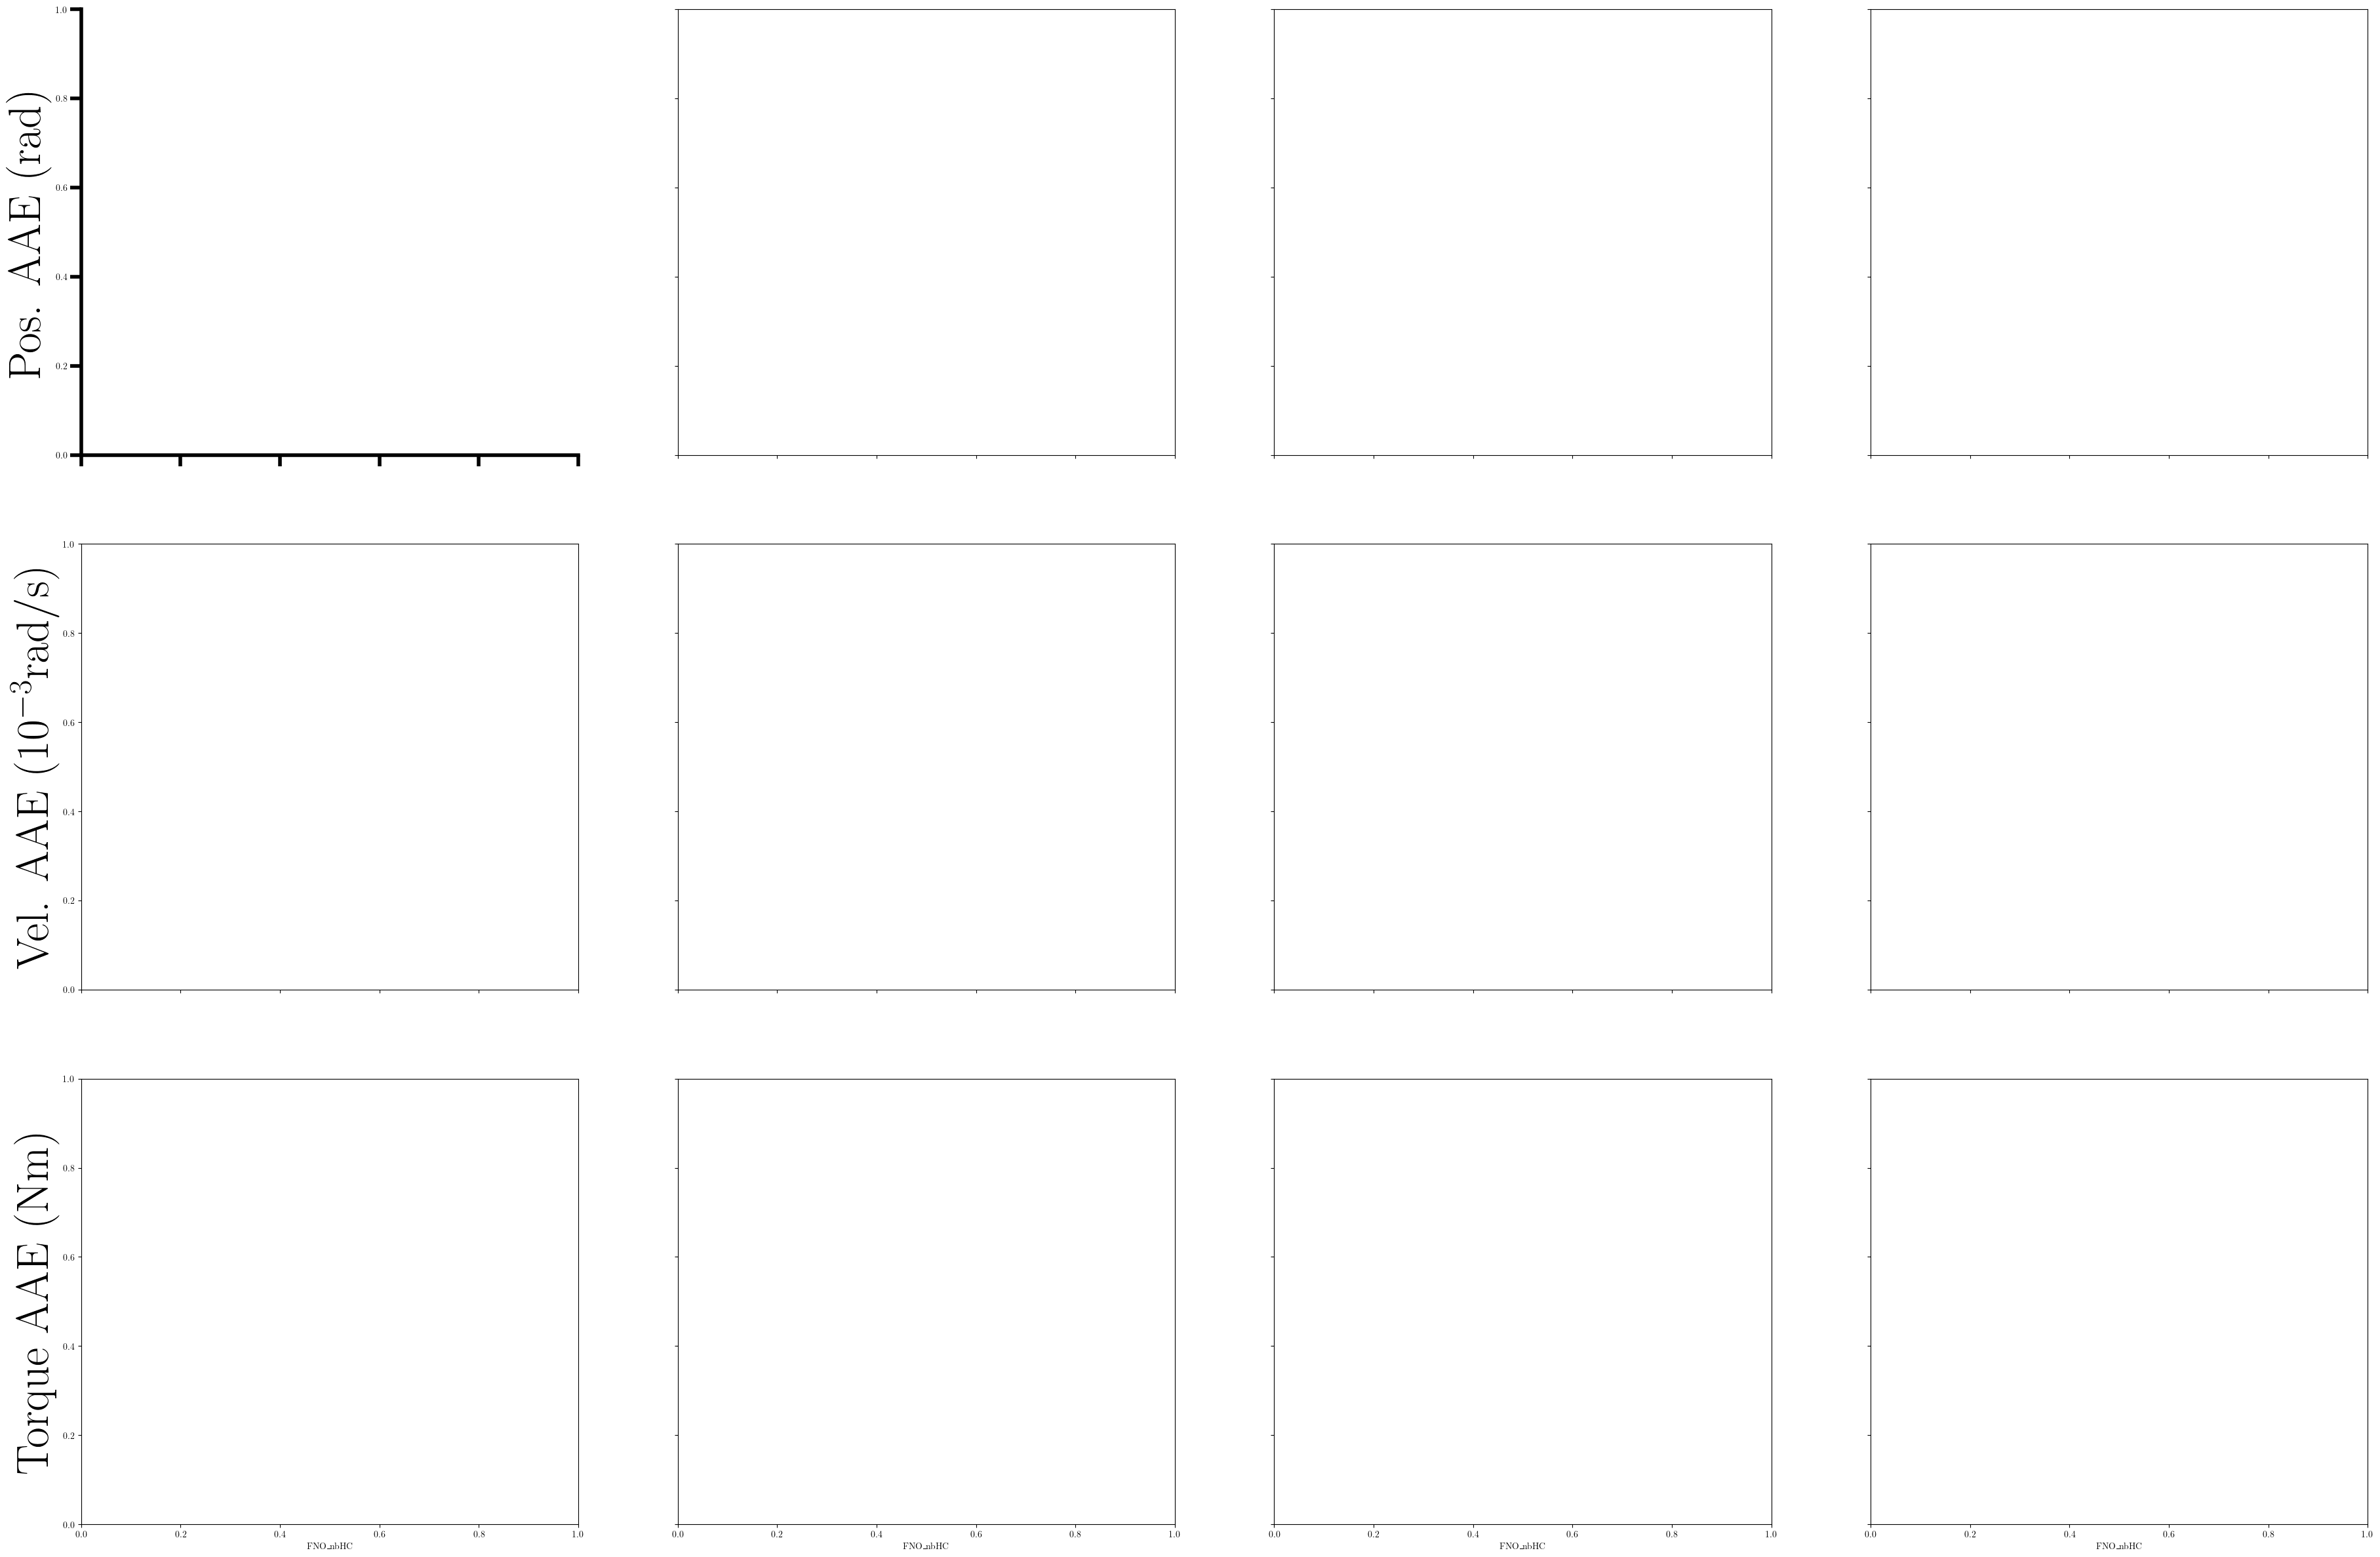

In [10]:
## Palette for shoulder and elbow
palette = ["#023e8a", '#9d0d14']

## Effect of fold on training dataset when fitting pos only
fig, axes = plt.subplots(3, 4, figsize = (4.5*pltSizex, 3*pltSizex), sharex = True, sharey = 'row')

## POSITION AAE SHO/ELB
# Training
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, linewidth = 10, markers = 's', ax = axes[0,0])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,0])
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, linewidth = 10, markers = 's', ax = axes[0,1])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,1])
# Evaluation
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[0,2])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,2])
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = fullEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[0,3])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = fullEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,3])

## VELOCITY AAE SHO/ELB
# Training
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,0])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,0])
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,1])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,1])
# Evaluation
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,2])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,2])
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = fullEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,3])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = fullEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,3])

## TORQUE AAE SHO/ELB
# Training
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,0])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,0])
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,1])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,1])
# Evaluation
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,2])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,2])
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,3])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = fullEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,3])

set_axis_fig_ModesHC_effect(fig, axes, palette)

fig.tight_layout()

# plt.savefig('./Unprocessed_Figures/FNO_NoFoldEffect.svg', format='svg')

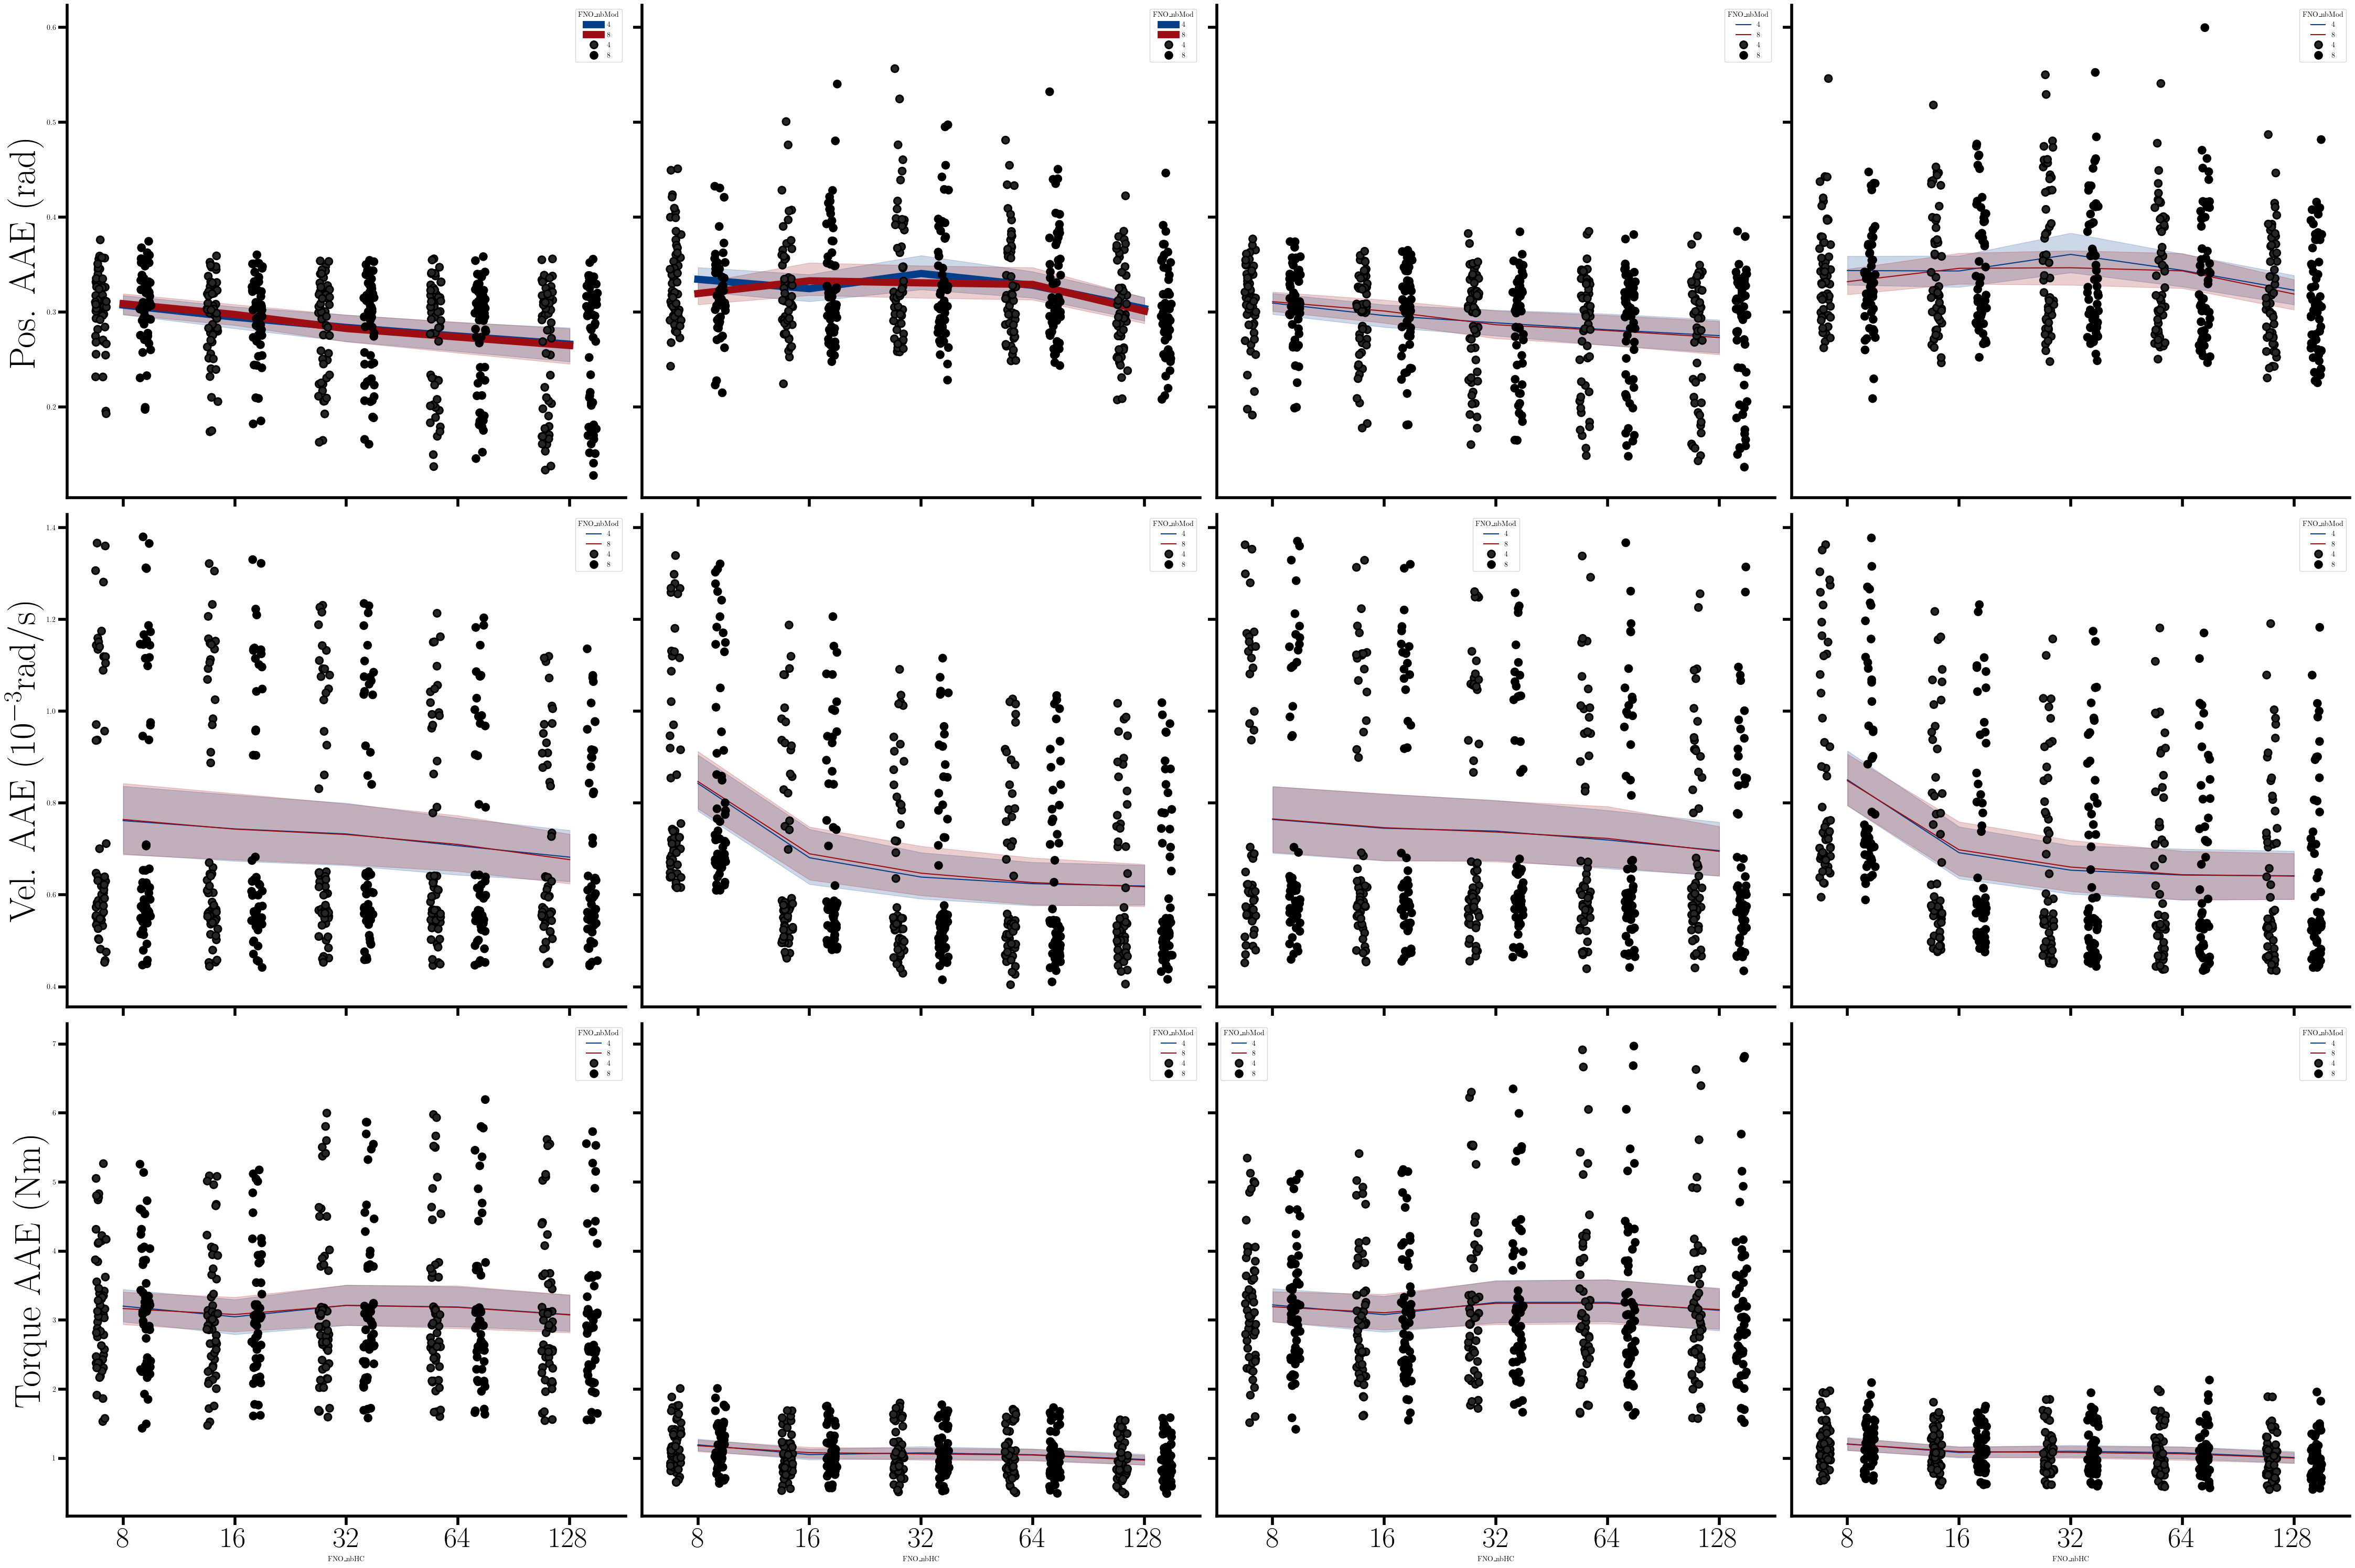

In [ ]:
## Palette for shoulder and elbow
palette = ["#023e8a", '#9d0d14']

## Effect of fold on training dataset when fitting pos only
fig, axes = plt.subplots(3, 4, figsize = (4.5*pltSizex, 3*pltSizex), sharex = True, sharey = 'row')

## POSITION AAE SHO/ELB
# Training
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = posTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, linewidth = 10, markers = 's', ax = axes[0,0])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = posTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,0])
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = posTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, linewidth = 10, markers = 's', ax = axes[0,1])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = posTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,1])
# Evaluation
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = posEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[0,2])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = posEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,2])
sns.lineplot(x = 'FNO_nbHC', y = 'posAAE', data = posEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[0,3])
sns.stripplot(x = 'FNO_nbHC', y = 'posAAE', data = posEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[0,3])

## VELOCITY AAE SHO/ELB
# Training
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = posTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,0])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = posTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,0])
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = posTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,1])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = posTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,1])
# Evaluation
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = posEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,2])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = posEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,2])
sns.lineplot(x = 'FNO_nbHC', y = 'velAAE', data = posEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[1,3])
sns.stripplot(x = 'FNO_nbHC', y = 'velAAE', data = posEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[1,3])

## TORQUE AAE SHO/ELB
# Training
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = posTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,0])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = posTrainRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,0])
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = posTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,1])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = posTrainRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,1])
# Evaluation
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = posEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,2])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = posEvalRes_FNO_s_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,2])
sns.lineplot(x = 'FNO_nbHC', y = 'tauAAE', data = posEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = palette, ax = axes[2,3])
sns.stripplot(x = 'FNO_nbHC', y = 'tauAAE', data = posEvalRes_FNO_e_subj, hue = 'FNO_nbMod', palette = 'dark:k', linewidth = 2, dodge = True, edgecolor = 'k', size = 10, ax = axes[2,3])

set_axis_fig_ModesHC_effect(fig, axes, palette)

fig.tight_layout()

# plt.savefig('./Unprocessed_Figures/FNO_NoFoldEffect.svg', format='svg')

In [ ]:
all_FNOFittings_av_mod_subj = all_FNOFittings.groupby()